In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 41


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

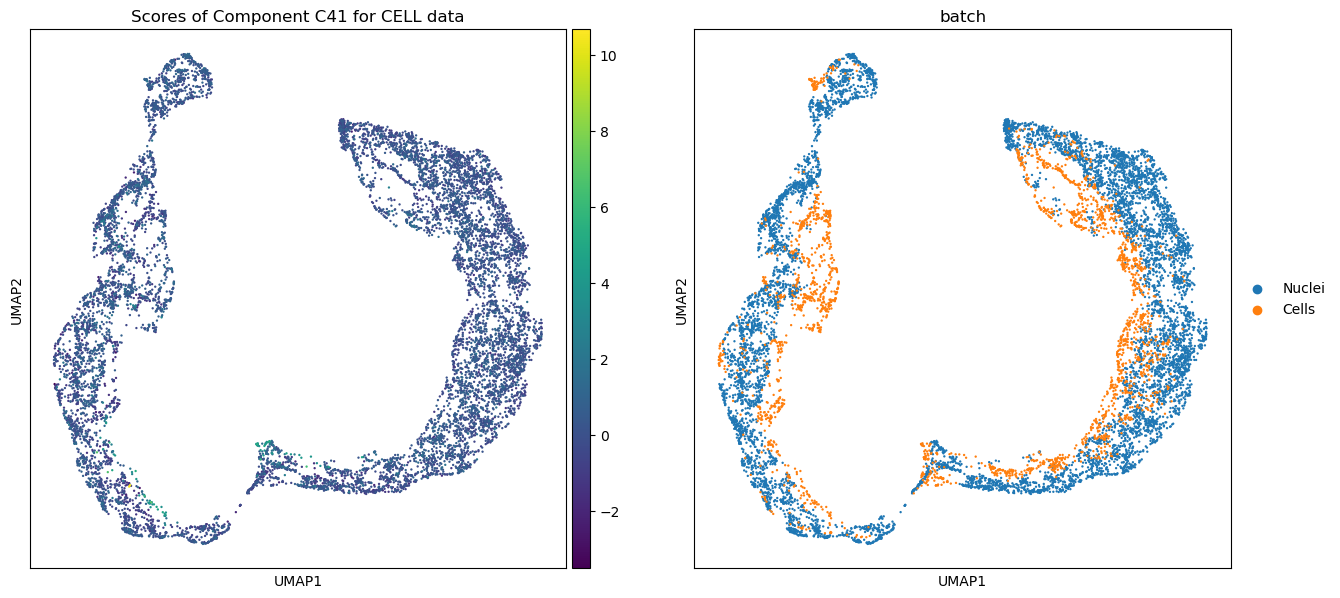

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

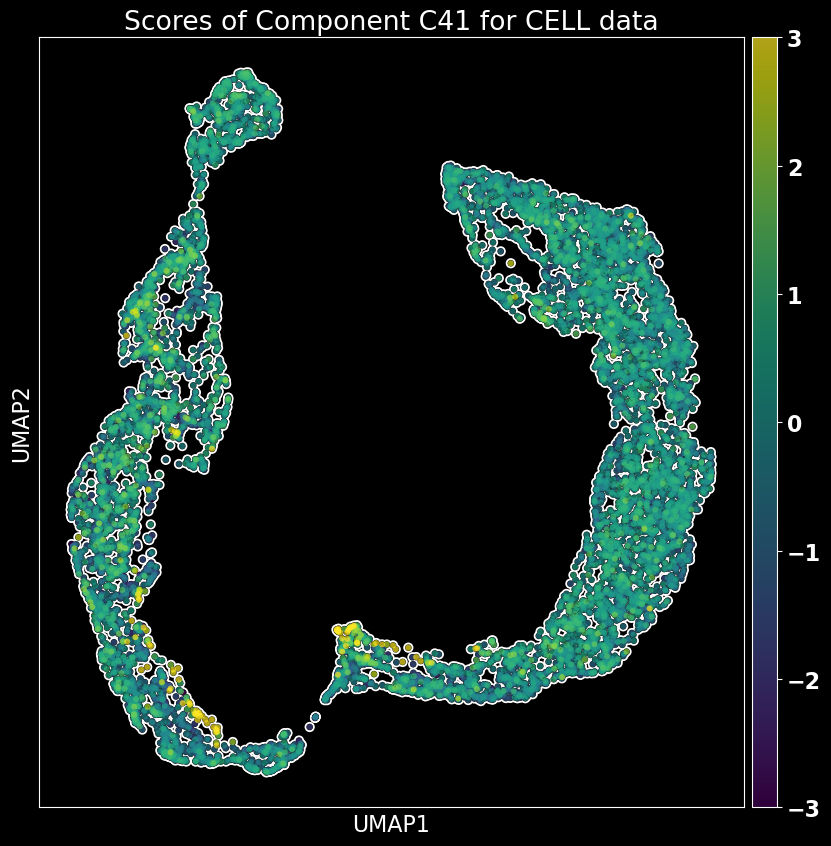

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

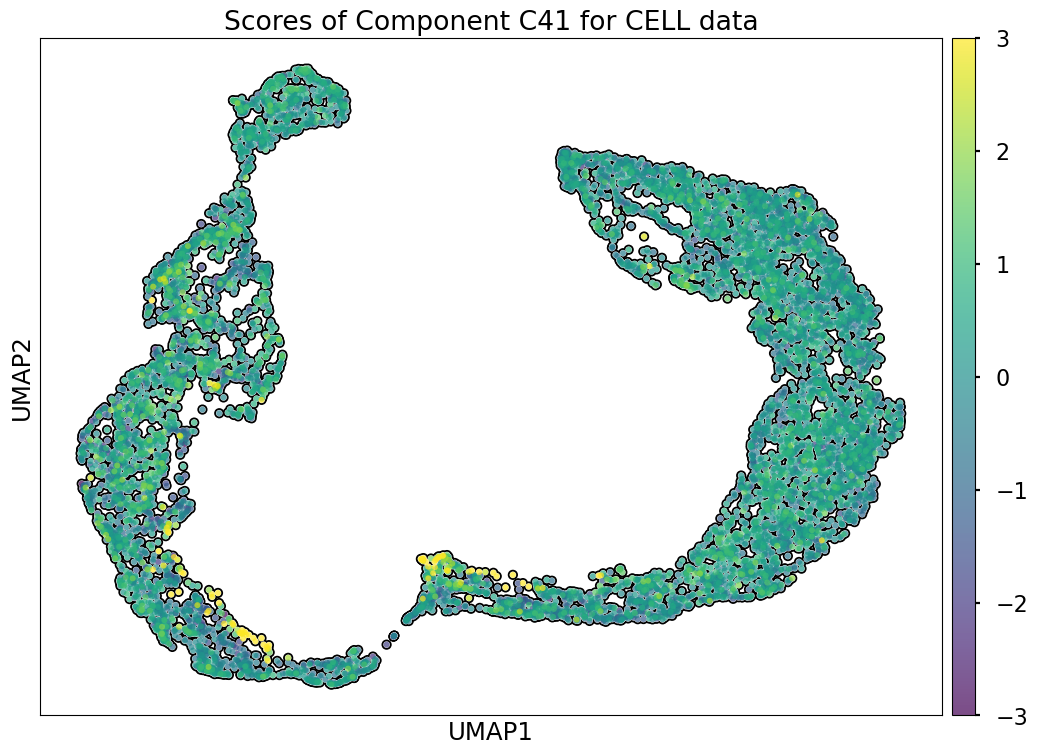

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

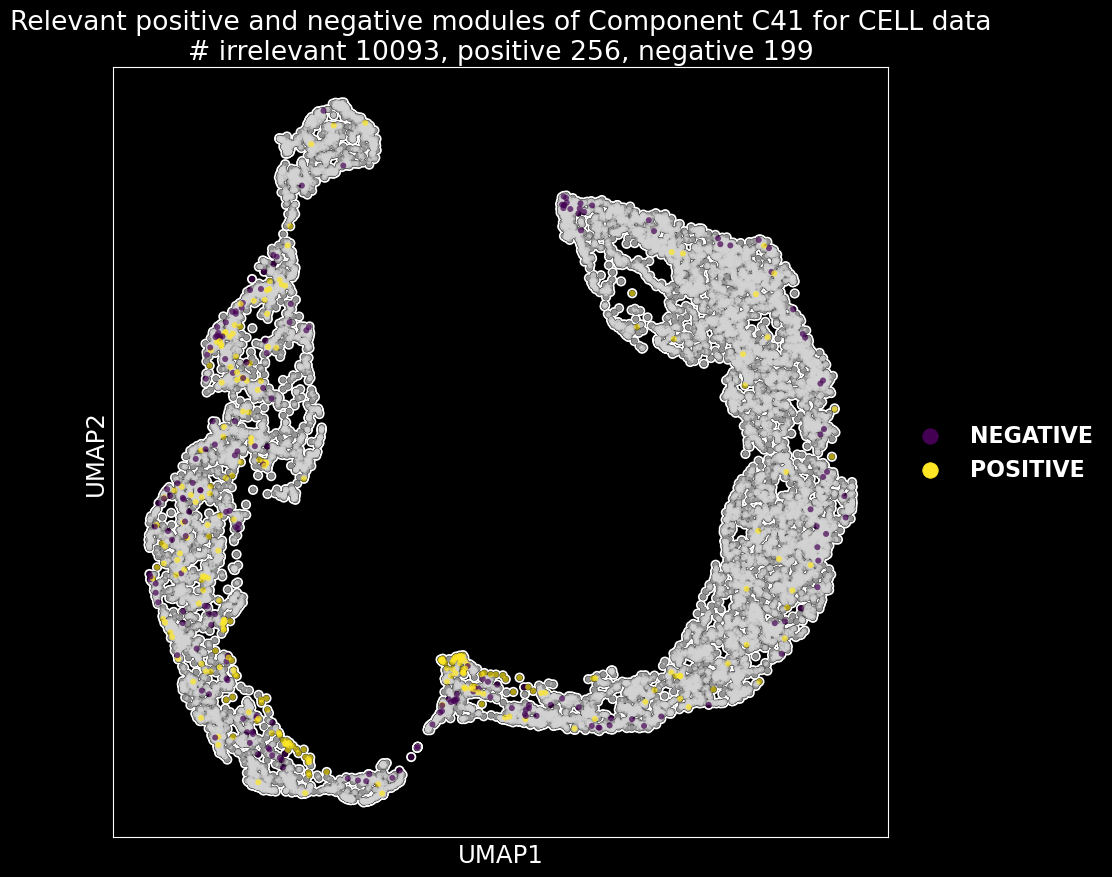

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

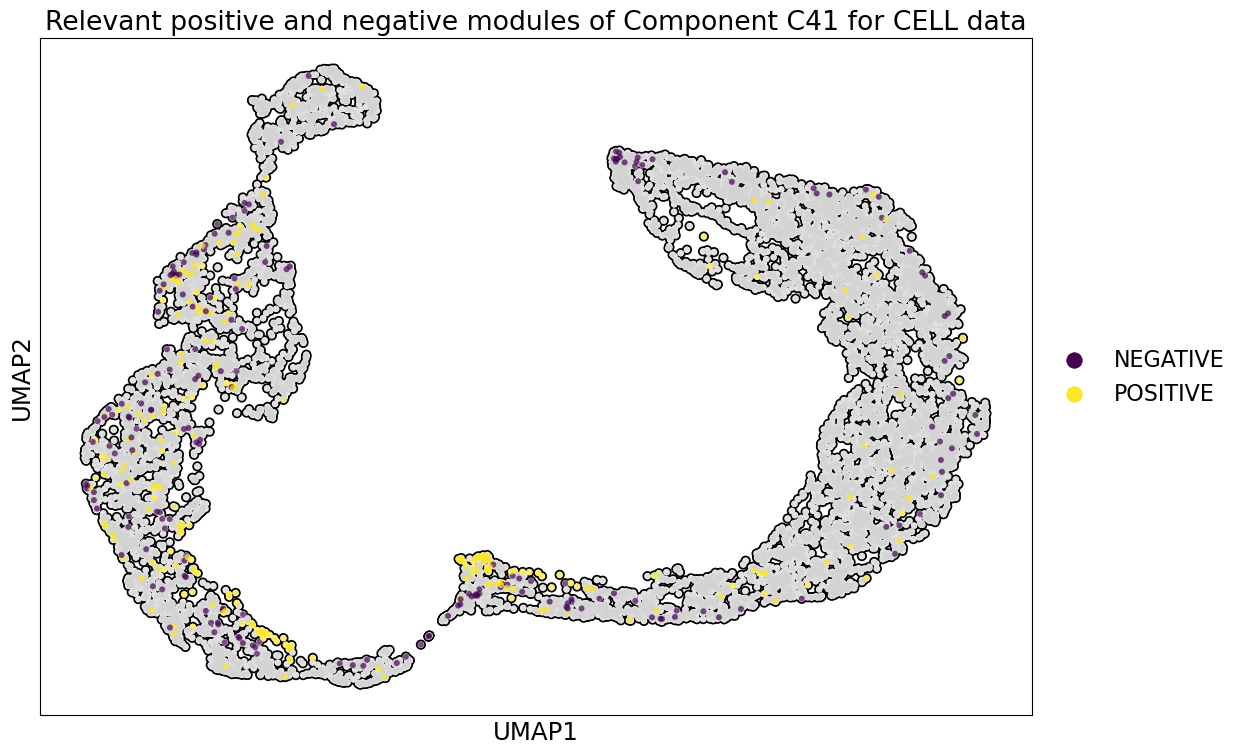

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.9295621153846156 var: 0.5643534328962722
Positive scores cells  - mean: 3.7733183999999995 var: 1.4578123661697482


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.791539565217391 var: 0.3001889573290387
Negative scores cells  - mean: -2.348829736842105 var: 0.30360318041020895


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=14.776885465896205, pvalue=2.0215241747158004e-48)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-9.849100935445307, pvalue=1.0717832095530078e-22)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C41', ylabel='Count'>

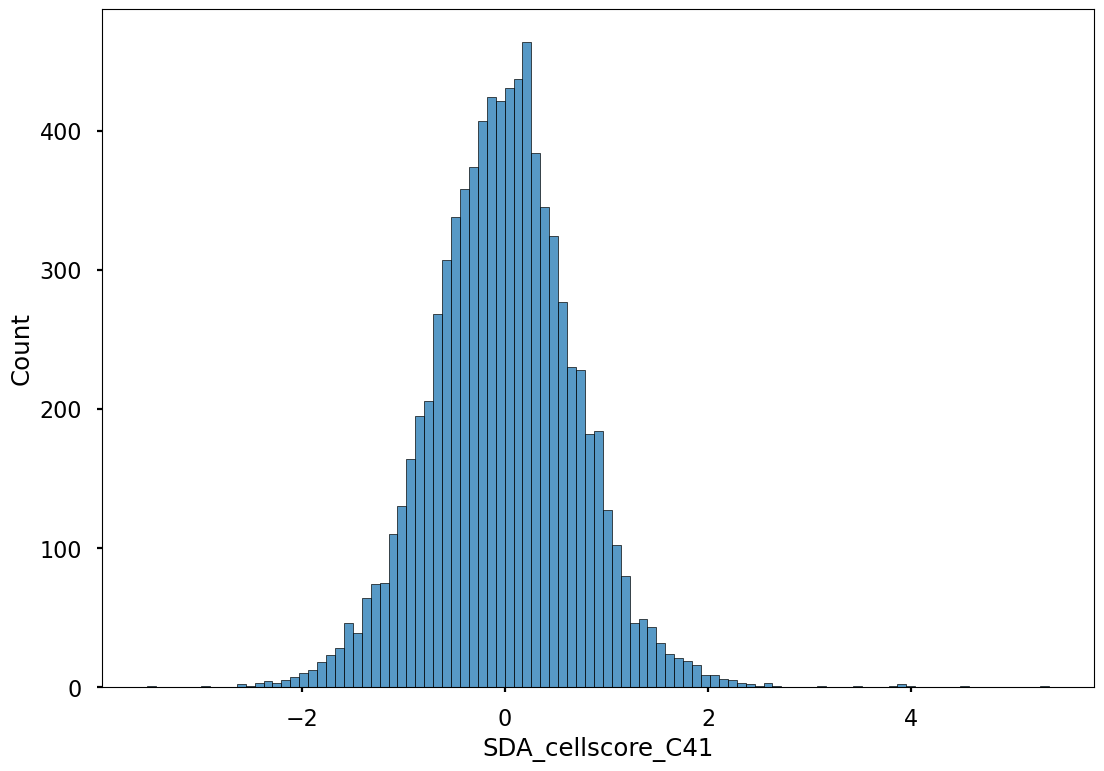

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C41', ylabel='Count'>

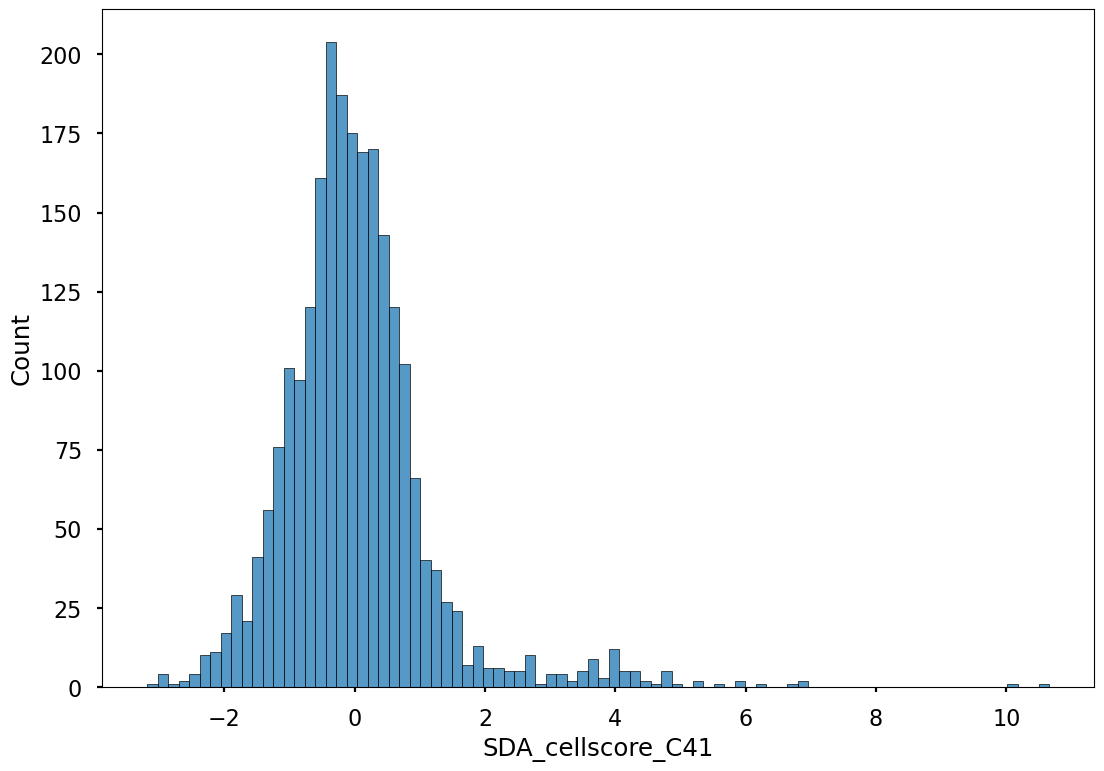

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C41: 473


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

LOC469457
CEP104
CENPS
KDM1A
SRRM1
SYF2
NUDC
SFPQ
YBX1
EBNA1BP2
NASP
HOOK1
USP1
MIER1
SERBP1
ZRANB2
RPF1
SSX2IP
PKN2
ZNF644
RPL5
CCDC18
DNTTIP2
ATP5PB
DDX20
CSDE1
SYCP1
SPAG17
UBE2Q1
CFAP45
NUF2
LOC107969148
BLZF1
CCDC181
PRRC2C
CACYBP
AXDND1
CEP350
TPR
KDM5B
CENPF
RRP15
EPRS
RBM34
ARID4B
ADSS
DESI2
HNRNPU
MYT1L
ODC1
DDX1
SMC6
SF3B6
DNAJC27
DRC1
PPM1G
SLC4A1AP
LCLAT1
MEMO1
GPATCH11
CEBPZ
GTF2A1L
ERLEC1
SPTBN1
CCDC88A
CFAP36
CCT4
ZNF638
SEPT10
LOC107971394
LOC107973562
ANKRD36C
LOC741694
TSGA10
EIF5B
ACTR3
NIFK
TSN
LOC744297
PRPF40A
BAZ2B
PSMD14
CCDC173
CIR1
CHN1
PLEKHA3
PPP1R1C
FSIP2
ZC3H15
CCDC150
SGO2
C2CD6
EEF1B2
XRCC5
ARPC2
DNAJB2
CUL3
NCL
CRBN
CCDC174
GOLGA4
NKTR
SNRK
KIF15
RHOA
PHF7
C3H3orf67
PSMD6
IFT57
DZIP3
ATG3
CCDC191
STXBP5L
GOLGB1
UBA5
CEP63
U2SURP
DHX36
GMPS
KCNAB1
ZBBX
PDCD10
NDUFB5
CCDC39
FXR1
DCUN1D1
CCDC50
XXYLT1
PPP1R2
IQCG
GRK4
LYAR
MRFAP1
FBXL5
FAM200B
RFC1
GK2
MRPL1
CCDC158
SDAD1
CABS1
YTHDC1
EXOC1
NFXL1
COMMD8
SMARCAD1
CENPE
AIMP1
LOC107974097
LARP7
SMARCA5
PALLD

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C41: 451


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

AURKAIP1
PLEKHM2
ARID1A
ATP5IF1
ZMYM6
AGO3
PABPC4
TESK2
LOC742376
RPL35A
TM2D1
MTF2
BCAR3
GSTM3
RAP1A
RNF115
C1H1orf56
NUP210L
KLHDC9
RC3H1
RABIF
ETNK2
MDM4
ESRRG
CNST
RPS7
ADAM17
UBXN2A
ASXL2
OST4
PRR30
MRPL33
BABAM2
SPDYA
YPEL5
EML4
MTA3
CAMKMT
CALM2
KIAA1841
ANXA4
ASPRV1
SNRPG
ANKRD53
LOC107973527
CHCHD5
MAP3K2
LOC741724
MZT2B
ARL6IP6
PKP4
SP3
ATF2
LNPK
SATB2
LOC107973900
LOC112208398
RPL37A
TNP1
RETREG2
OBSL1
LOC459972
PID1
PDE6D
UBE2F
COPS9
FARP2
STK25
RAF1
NR2C2
CAPN7
RPL15
SLC4A7
ANO10
TMA7
UQCRC1
TMEM89
NDUFAF3
IP6K1
ZMYND10
RPL29
SELENOK
PDZRN3
ROBO1
RPN1
MSL2
ARMC8
CLSTN2
LOC107970827
PLD1
UBXN7
C4H4orf48
FAM53A
DCAF4L1
SPINK2
LOC107974333
COX7B2
LOC104006140
MTTP
H2AFZ
LEF1
RPL34
LOC104006183
LOC107974487
SNX25
LOC107974613
ROPN1L
KIAA0825
RPS23
LOC737107
CDC20B
IL6ST
RPL37
FTMT
CATSPER3
PKD2L2
SIL1
PURA
RPS14
PTTG1
C5H5orf58
CREBRF
CPEB4
LMAN2
RMND5B
LOC107966375
LOC741943
LOC112209441
HIST1H2AA
PRRC2A
CUTA
UQCC2
LOC107975129
LOC462679
USP49
COX7A2
LOC741253
RPS12
TULP4
PAC

#### Cells scores by cluster

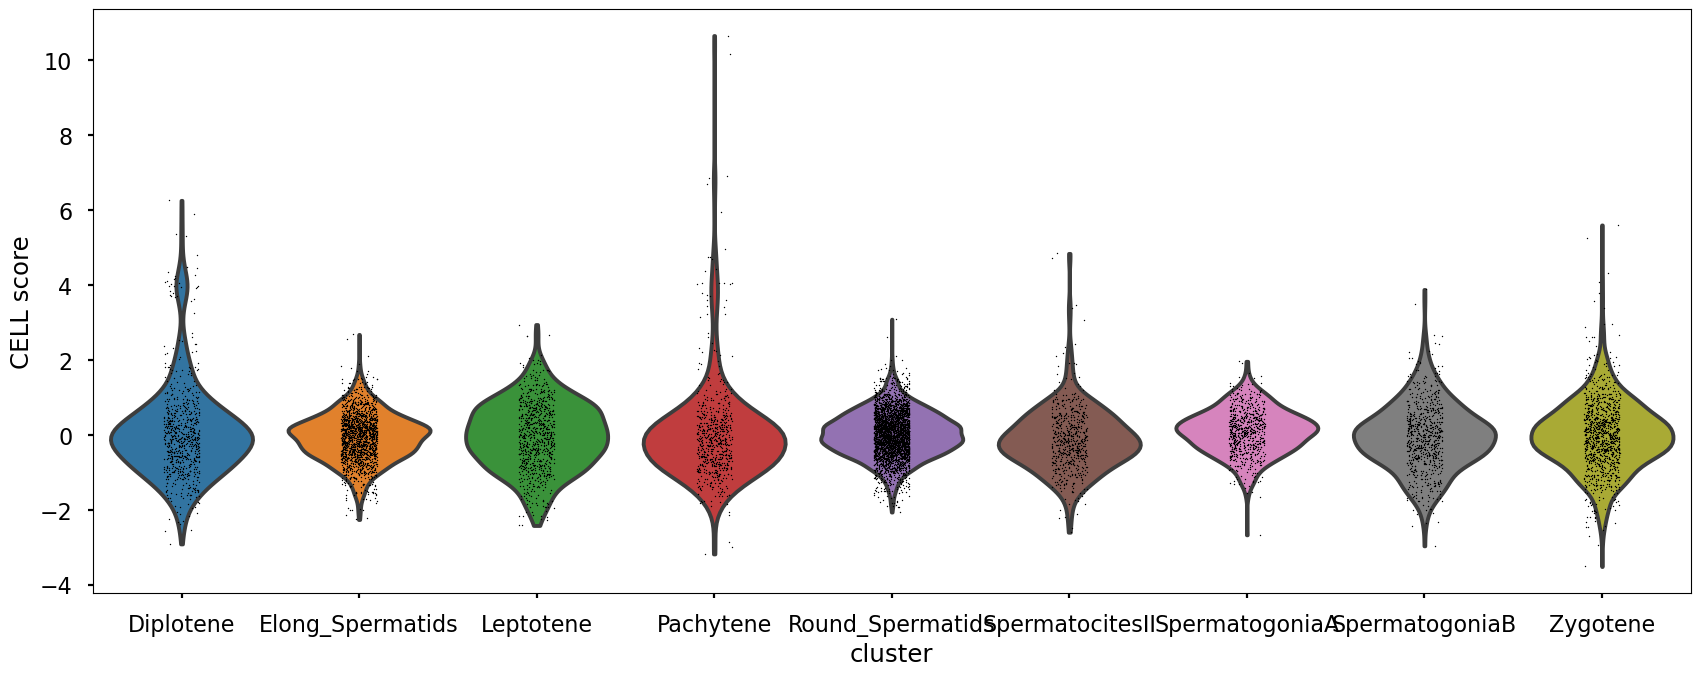

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

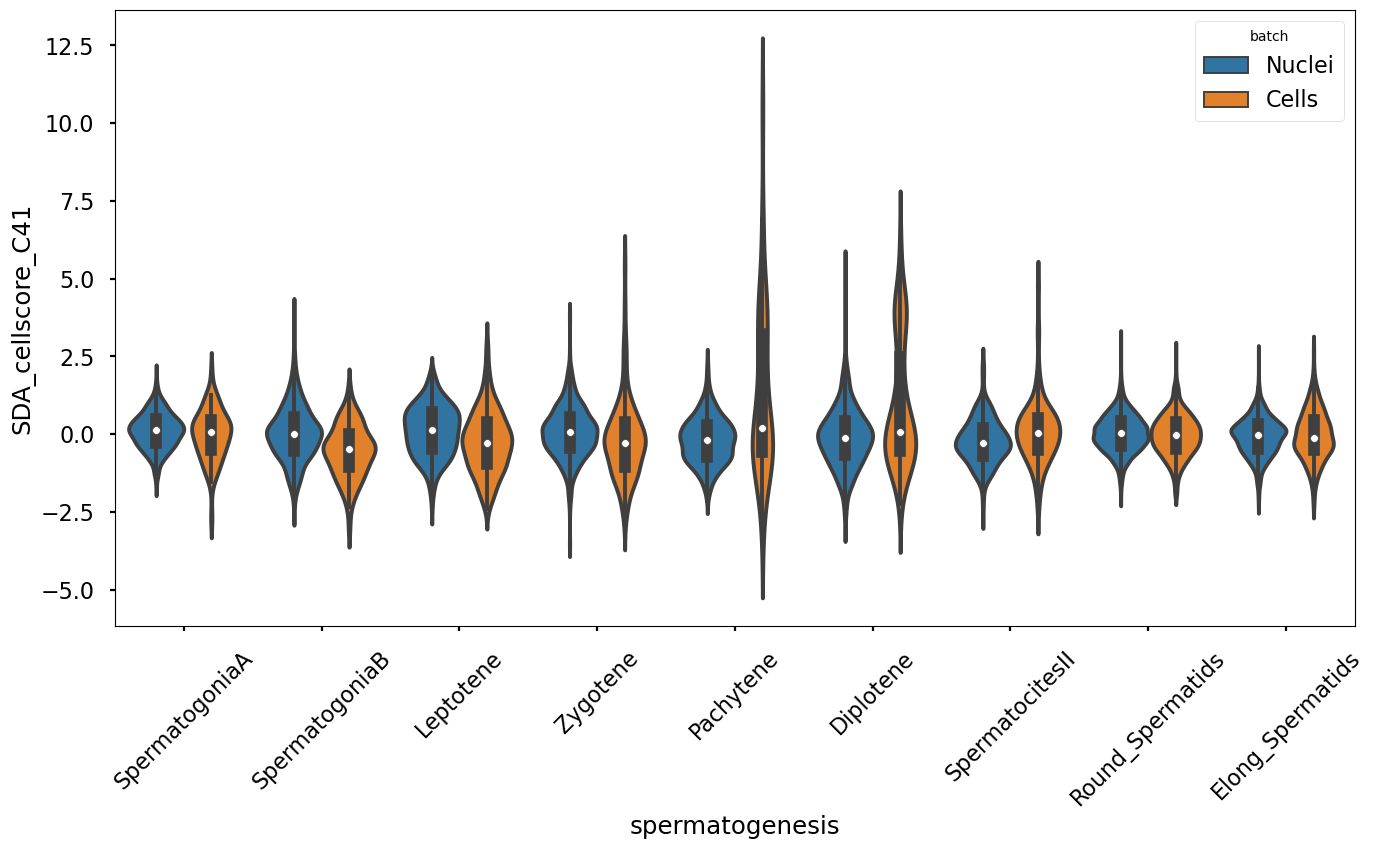

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C41')

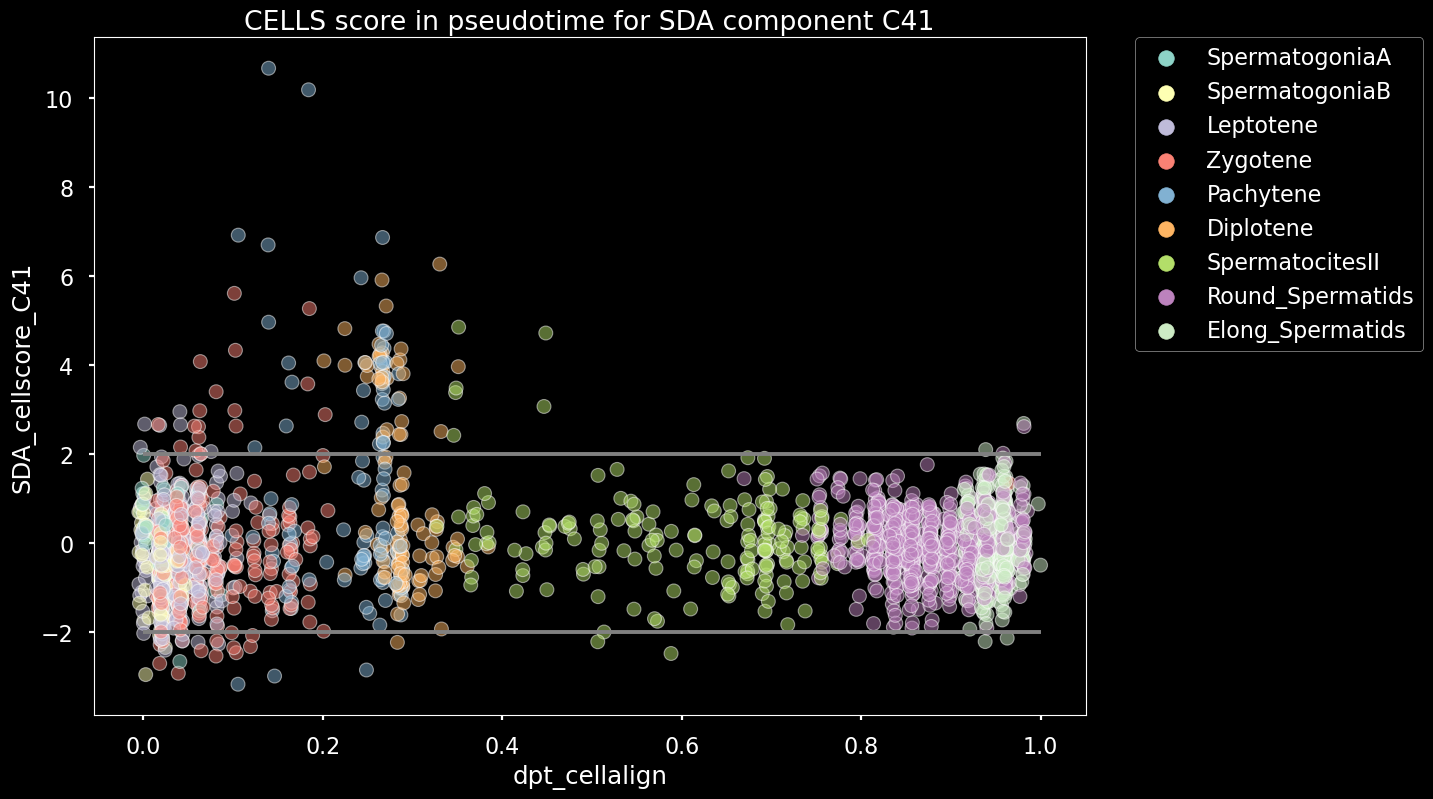

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C41')

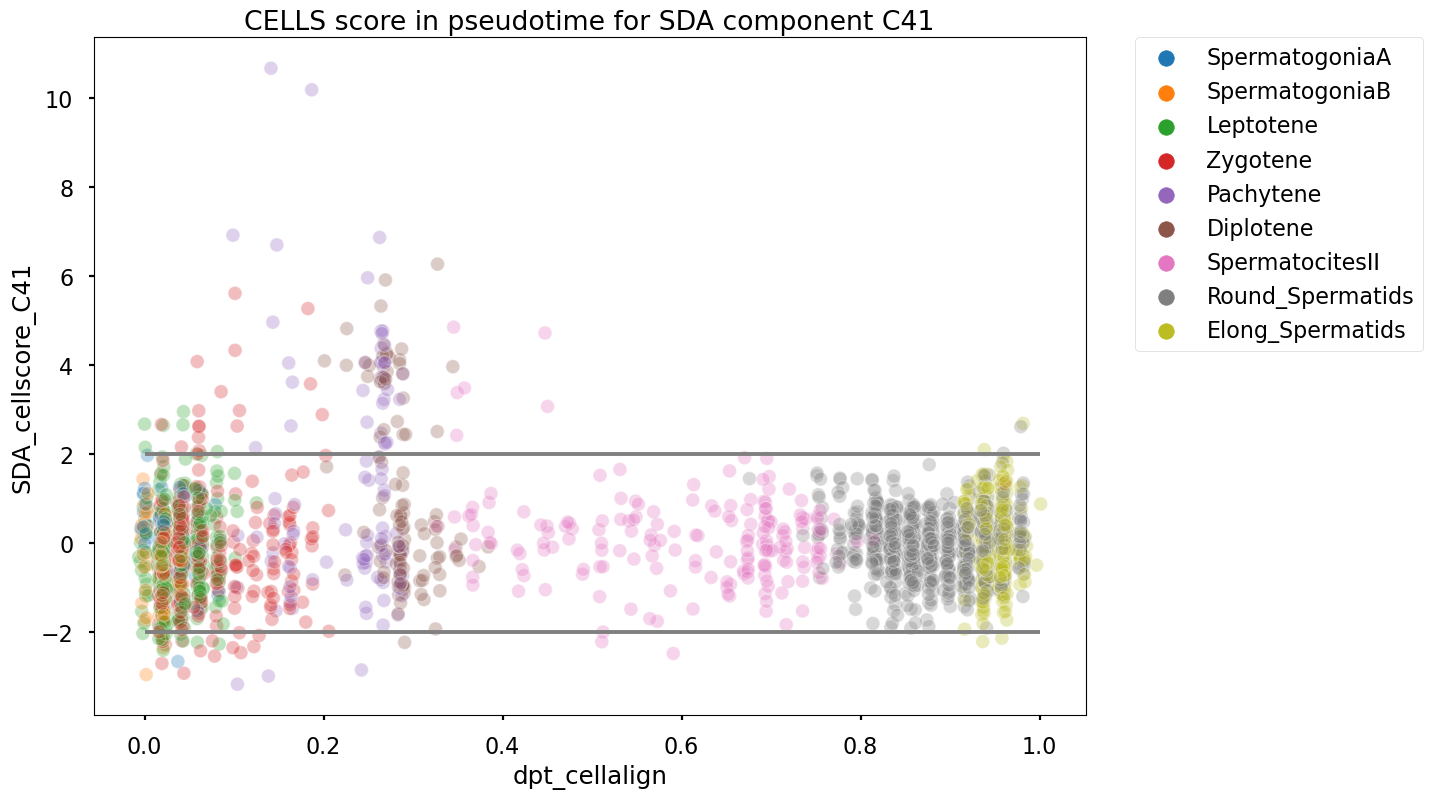

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C41')

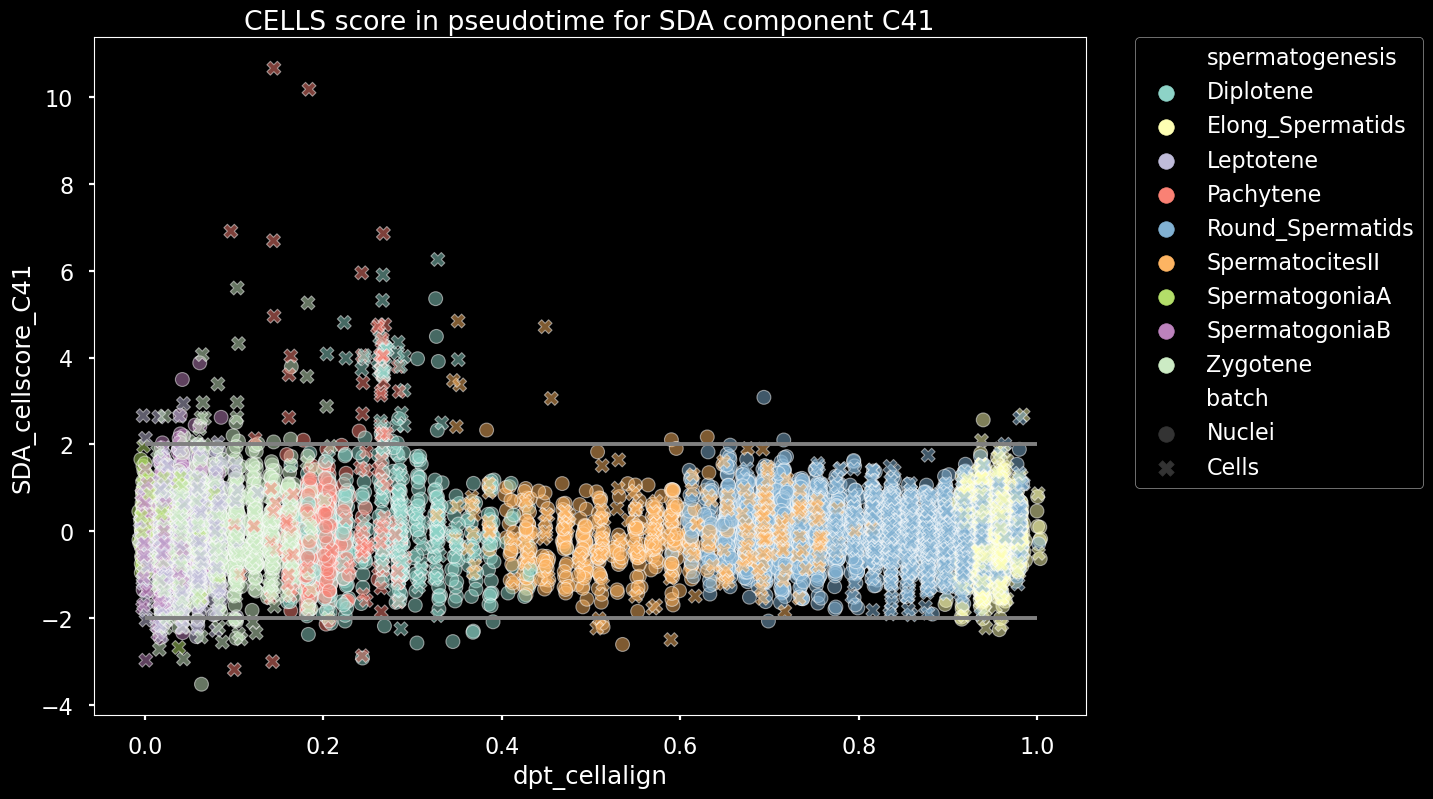

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C41')

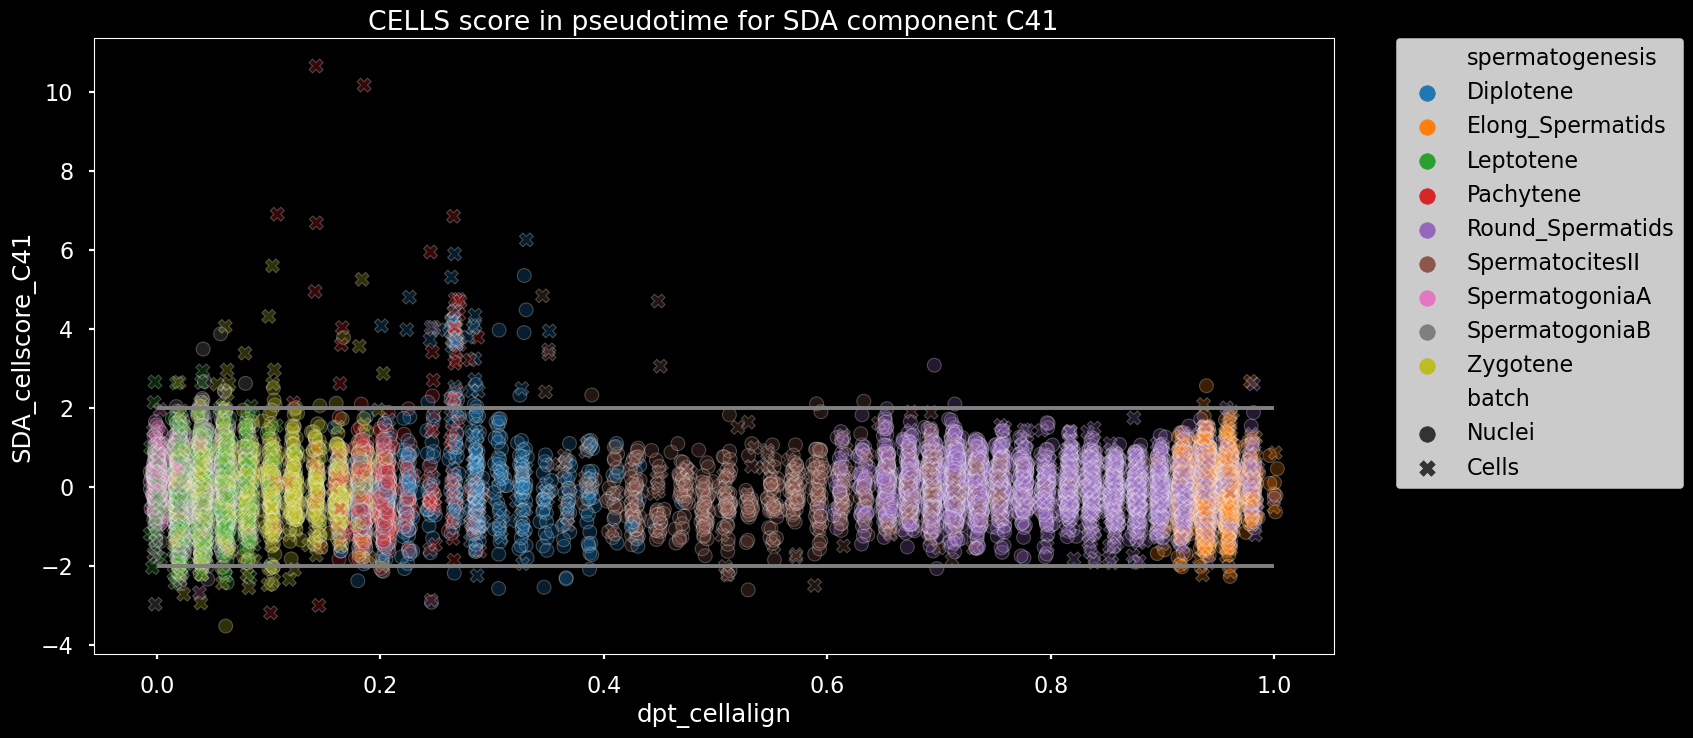

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Spliceosome,15/150,2.842969e-06,4.719329e-04,0,0,4.704512,60.079735,RBM17;RBM25;SF3B2;DDX46;SF3B6;HNRNPU;CDC5L;PRP...
166,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),59/780,2.553868e-15,5.669587e-13,0,0,3.717174,124.901370,RPL5;SRP19;SRP54;HNRNPU;PWP1;CHD1;RABGEF1;NUB1...
167,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,74/1195,2.168381e-14,2.406903e-12,0,0,3.045178,95.808020,RPL5;SRP19;SYCP1;SRP54;BUB1B;ARID4A;DEUP1;PWP1...
168,GO_Cellular_Component_2023,Nucleolus (GO:0005730),55/771,2.731696e-13,2.021455e-11,0,0,3.456888,100.003210,RPL5;SRP19;SRP54;PWP1;RABGEF1;NUB1;SNAPC1;NUSA...
169,GO_Cellular_Component_2023,Chromosome (GO:0005694),23/164,7.185118e-12,3.987740e-10,0,0,7.027234,180.311863,IK;ESCO1;NIFK;SYCP1;SMARCA5;NOL7;HNRNPU;DNTTIP...
170,GO_Cellular_Component_2023,Nucleus (GO:0005634),168/4487,4.002210e-11,1.776981e-09,0,0,1.939538,46.435628,RPL5;MRE11;KDM1A;MYT1L;GMNN;HNRNPU;ARID4A;SMC5...
171,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,177/5175,1.509375e-08,5.584688e-07,0,0,1.738285,31.304752,RPL5;SLC4A1AP;MRE11;KDM1A;MYT1L;GMNN;HNRNPU;AR...
172,GO_Cellular_Component_2023,Spindle (GO:0005819),20/210,1.434622e-07,4.549802e-06,0,0,4.493319,70.802106,NUDC;CSNK1A1;CUL3;USP44;HNRNPU;BUB1B;HMMR;AURK...
173,GO_Cellular_Component_2023,Microtubule Cytoskeleton (GO:0015630),23/342,7.678598e-06,2.130811e-04,0,0,3.077562,36.244672,OFD1;CCT2;NUDC;DST;CSNK1A1;BUB1B;HMMR;KIF27;KI...
174,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),13/143,3.605040e-05,8.892432e-04,0,0,4.216739,43.139740,NUDC;CUL3;USP44;HNRNPU;AURKA;CENPE;TAF1D;TPR;N...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Spliceosome,15/150,4.719329e-04,4.704512,60.079735,RBM17;RBM25;SF3B2;DDX46;SF3B6;HNRNPU;CDC5L;PRP...,41P,Yes,256
166,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),59/780,5.669587e-13,3.717174,124.901370,RPL5;SRP19;SRP54;HNRNPU;PWP1;CHD1;RABGEF1;NUB1...,41P,Yes,256
167,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,74/1195,2.406903e-12,3.045178,95.808020,RPL5;SRP19;SYCP1;SRP54;BUB1B;ARID4A;DEUP1;PWP1...,41P,Yes,256
168,GO_Cellular_Component_2023,Nucleolus (GO:0005730),55/771,2.021455e-11,3.456888,100.003210,RPL5;SRP19;SRP54;PWP1;RABGEF1;NUB1;SNAPC1;NUSA...,41P,Yes,256
169,GO_Cellular_Component_2023,Chromosome (GO:0005694),23/164,3.987740e-10,7.027234,180.311863,IK;ESCO1;NIFK;SYCP1;SMARCA5;NOL7;HNRNPU;DNTTIP...,41P,Yes,256
170,GO_Cellular_Component_2023,Nucleus (GO:0005634),168/4487,1.776981e-09,1.939538,46.435628,RPL5;MRE11;KDM1A;MYT1L;GMNN;HNRNPU;ARID4A;SMC5...,41P,Yes,256
171,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,177/5175,5.584688e-07,1.738285,31.304752,RPL5;SLC4A1AP;MRE11;KDM1A;MYT1L;GMNN;HNRNPU;AR...,41P,Yes,256
172,GO_Cellular_Component_2023,Spindle (GO:0005819),20/210,4.549802e-06,4.493319,70.802106,NUDC;CSNK1A1;CUL3;USP44;HNRNPU;BUB1B;HMMR;AURK...,41P,Yes,256
173,GO_Cellular_Component_2023,Microtubule Cytoskeleton (GO:0015630),23/342,2.130811e-04,3.077562,36.244672,OFD1;CCT2;NUDC;DST;CSNK1A1;BUB1B;HMMR;KIF27;KI...,41P,Yes,256
174,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),13/143,8.892432e-04,4.216739,43.139740,NUDC;CUL3;USP44;HNRNPU;AURKA;CENPE;TAF1D;TPR;N...,41P,Yes,256


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,33/158,1.206850e-22,2.763688e-20,0,0,12.267789,619.141325,RPL34;RPLP1;MRPL33;RPS14;RPS16;RPL18A;RPS19;RP...
1,KEGG_2021_Human,Coronavirus disease,34/232,3.536015e-18,4.048738e-16,0,0,7.968583,320.205792,RPL34;RPLP1;RPS14;RPS16;RPL18A;RPS19;RPL36;RPL...
2,KEGG_2021_Human,Parkinson disease,20/249,1.038116e-06,6.630339e-05,0,0,3.914933,53.940355,NDUFB8;NDUFA11;NDUFA3;COX7A2;UQCR10;UBE2G2;COX...
3,KEGG_2021_Human,Alzheimer disease,25/369,1.158138e-06,6.630339e-05,0,0,3.276320,44.783022,RTN3;NDUFB8;NDUFA11;ATP2A2;COX7A2;UQCR10;CACNA...
4,KEGG_2021_Human,Huntington disease,21/306,6.831823e-06,3.128975e-04,0,0,3.301053,39.262453,NDUFB8;NDUFA11;NDUFA3;COX7A2;UQCR10;NRF1;AMBRA...
5,KEGG_2021_Human,Thermogenesis,17/232,2.218955e-05,8.469011e-04,0,0,3.522431,37.745976,ATF2;NDUFB8;NDUFA11;NDUFA3;TSC2;COX7A2;UQCR10;...
229,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),18/52,3.422178e-17,3.849950e-15,0,0,23.860209,904.628086,RPL41;RPL21;RPL34;RPLP1;RPL35A;RPL18A;RPL27A;R...
230,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),18/52,3.422178e-17,3.849950e-15,0,0,23.860209,904.628086,RPL41;RPL21;RPL34;RPLP1;RPL35A;RPL18A;RPL27A;R...
231,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),14/41,1.454603e-13,1.090952e-11,0,0,23.163658,684.691630,RPS9;RPS7;RPS5;RPS26;RPS14;RPS28;RPS16;RPS19;R...
232,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),14/42,2.137459e-13,1.202321e-11,0,0,22.335240,651.608043,RPS9;RPS7;RPS5;RPS26;RPS14;RPS28;RPS16;RPS19;R...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,33/158,2.763688e-20,12.267789,619.141325,RPL34;RPLP1;MRPL33;RPS14;RPS16;RPL18A;RPS19;RP...,41N,No,199
1,KEGG_2021_Human,Coronavirus disease,34/232,4.048738e-16,7.968583,320.205792,RPL34;RPLP1;RPS14;RPS16;RPL18A;RPS19;RPL36;RPL...,41N,No,199
2,KEGG_2021_Human,Parkinson disease,20/249,6.630339e-05,3.914933,53.940355,NDUFB8;NDUFA11;NDUFA3;COX7A2;UQCR10;UBE2G2;COX...,41N,No,199
3,KEGG_2021_Human,Alzheimer disease,25/369,6.630339e-05,3.276320,44.783022,RTN3;NDUFB8;NDUFA11;ATP2A2;COX7A2;UQCR10;CACNA...,41N,No,199
4,KEGG_2021_Human,Huntington disease,21/306,3.128975e-04,3.301053,39.262453,NDUFB8;NDUFA11;NDUFA3;COX7A2;UQCR10;NRF1;AMBRA...,41N,No,199
5,KEGG_2021_Human,Thermogenesis,17/232,8.469011e-04,3.522431,37.745976,ATF2;NDUFB8;NDUFA11;NDUFA3;TSC2;COX7A2;UQCR10;...,41N,No,199
229,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),18/52,3.849950e-15,23.860209,904.628086,RPL41;RPL21;RPL34;RPLP1;RPL35A;RPL18A;RPL27A;R...,41N,No,199
230,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),18/52,3.849950e-15,23.860209,904.628086,RPL41;RPL21;RPL34;RPLP1;RPL35A;RPL18A;RPL27A;R...,41N,No,199
231,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),14/41,1.090952e-11,23.163658,684.691630,RPS9;RPS7;RPS5;RPS26;RPS14;RPS28;RPS16;RPS19;R...,41N,No,199
232,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),14/42,1.202321e-11,22.335240,651.608043,RPS9;RPS7;RPS5;RPS26;RPS14;RPS28;RPS16;RPS19;R...,41N,No,199


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

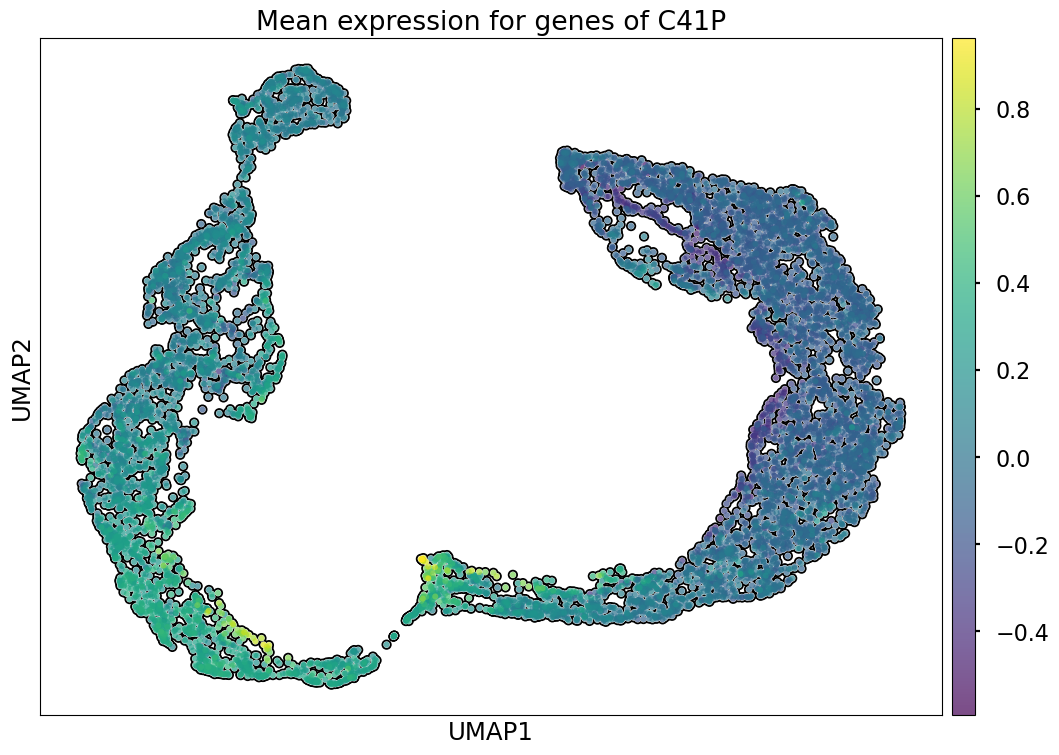

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

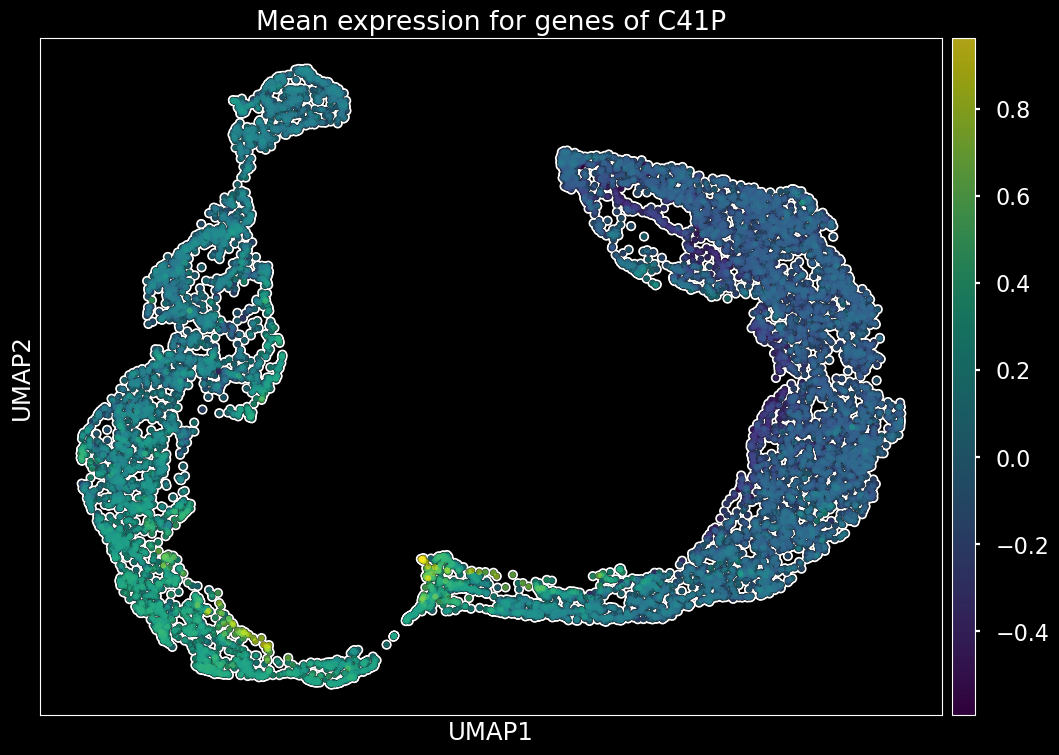

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

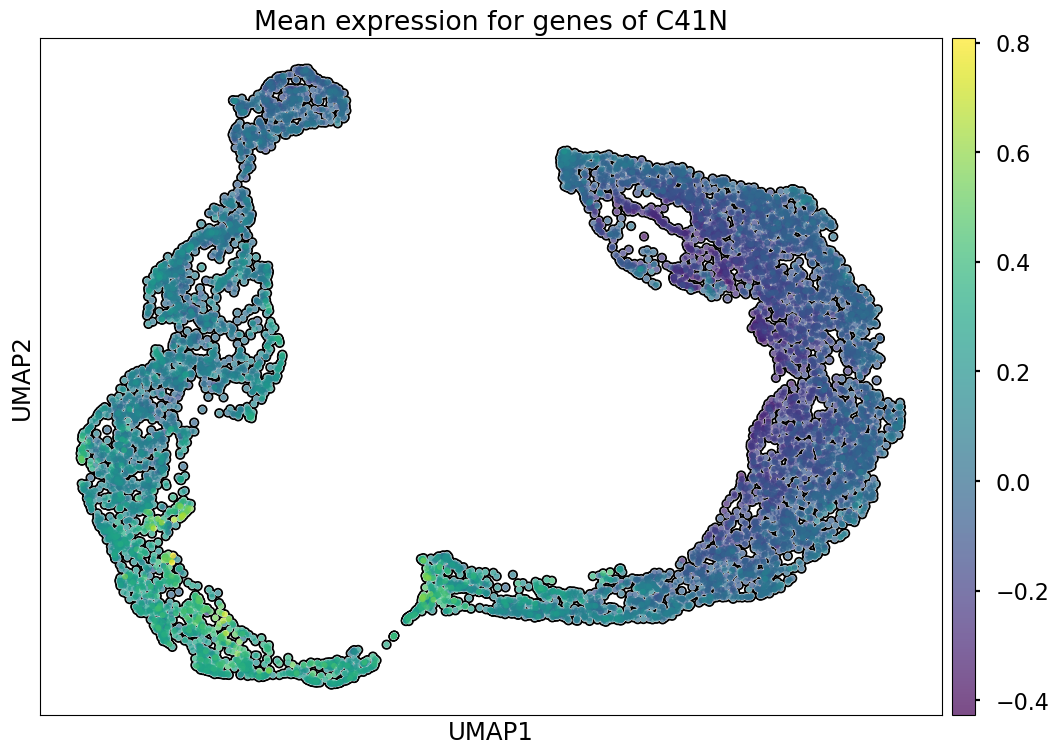

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

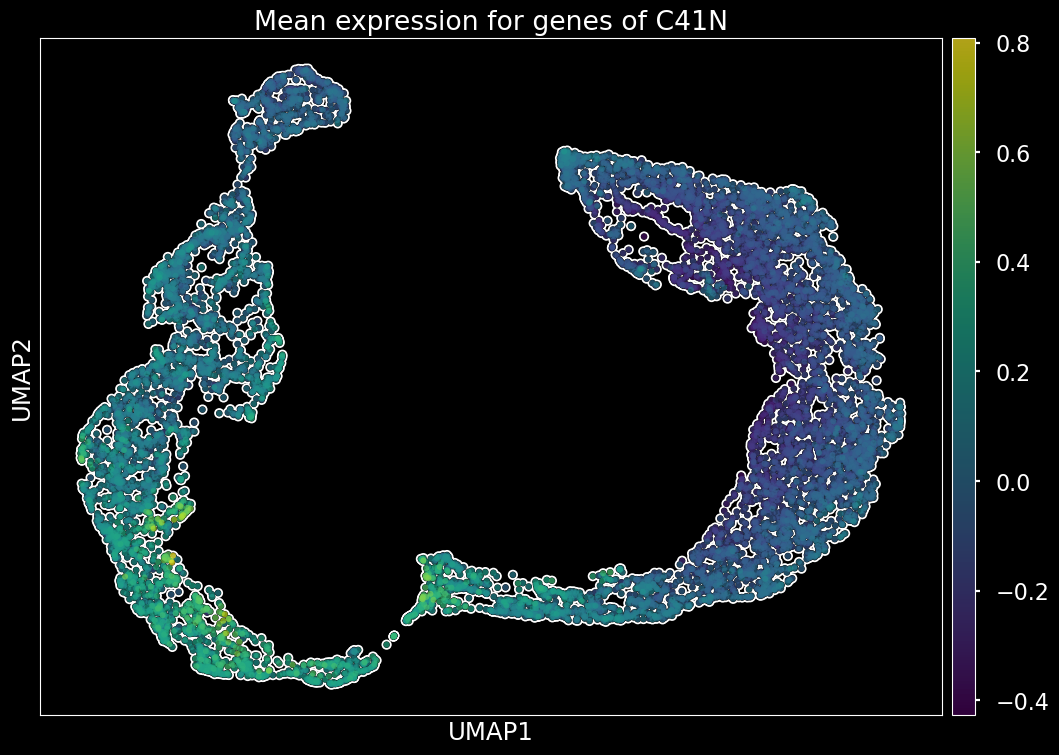

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)